In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv('placement.csv')

In [5]:
df.shape

(200, 2)

In [6]:
df.sample(4)

,cgpa,package
26,8.31,3.42
111,5.42,2.25
118,7.40,2.88
124,6.06,2.31


In [7]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


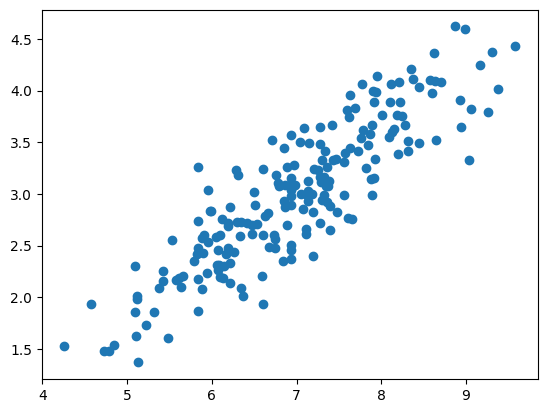

In [8]:
plt.scatter(x=df['cgpa'],y=df['package'])

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x=df.iloc[:,0:1]
y=df.iloc[:,1:2]

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
x_train.shape

(160, 1)

In [13]:
y_train.shape

(160, 1)

In [14]:
from sklearn.linear_model import LinearRegression

lc=LinearRegression()

In [15]:
lc.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
y_pred=lc.predict(x_test)

In [17]:
y_pred=pd.DataFrame(y_pred)

In [25]:
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,mean_squared_error,r2_score

In [26]:
print("MAE :",mean_absolute_error(y_test,y_pred))
print("MSE :",mean_squared_error(y_test,y_pred))
print("RMsE :",mean_absolute_error(y_test,y_pred))
print("R2",r2_score(y_test,y_pred))


MAE : 0.23150985393278373
MSE : 0.08417638361329656
RMsE : 0.23150985393278373
R2 0.7730984312051673


In [47]:
y_pred.head(5)

,0
0,2.780313
1,3.136352
2,3.199521
3,2.389819
4,3.526847


In [48]:
y_test.head(5)

,package
95,2.79
15,3.23
30,3.26
158,3.04
128,3.34


In [49]:
print(y_pred.shape)
print(y_test.shape)

(40, 1)
(40, 1)


In [54]:
y_pred


,0
0,2.780313
1,3.136352
2,3.199521
3,2.389819
4,3.526847
5,3.768035
6,3.165065
7,2.544868
8,3.176550
9,3.492392


In [60]:
y_test=y_test.reset_index(drop=True)

In [61]:
checkacuuracy=pd.concat([y_test,y_pred],axis=1)

In [62]:
checkacuuracy

,package,0
0,2.79,2.780313
1,3.23,3.136352
2,3.26,3.199521
3,3.04,2.389819
4,3.34,3.526847
5,4.21,3.768035
6,2.94,3.165065
7,2.87,2.544868
8,2.99,3.176550
9,3.58,3.492392


In [63]:
from sklearn.metrics import accuracy_score

In [79]:
df_test=df.sample(3)

In [80]:
df_test

,cgpa,package
141,6.76,3.18
181,8.22,3.89
27,5.42,2.16


In [81]:
df_test2=df_test.iloc[:,0:1]

In [82]:
df_test_prediction=lc.predict(df_test2)

In [83]:
df_test_prediction

array([[2.85496682],
       [3.69338127],
       [2.08546314]])

In [84]:
m=lc.coef_
print(m)
c=lc.intercept_
print(c)

[[0.57425647]]
[-1.02700694]
